# Lista de Exercício 6
### Introdução à Visão Computacional (SEL0339/SEL5886)

**Instruções:**

 1. Esta lista consiste de 2 exercícios.
 1. Deve-se colocar comentários nos códigos desenvolvidos.
 1. As perguntas devem ser respondidas também como comentários no arquivo.
 1. Colocar seu nome e número USP abaixo.
 1. Quaisquer problemas na execução das listas, entrar em contato com os monitores.
 1. Depois de terminado os exercícios, deve ser gerado um arquivo **extensão .ipynb** para ser enviado ao professor pelo E-DISCIPLINAS da disciplina até a data máxima de entrega.
 1. Caso não seja enviado, o aluno ficará sem nota.


---


 <table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/LAVI-USP/SEL0339-SEL5886_2024/blob/main/praticas/Lista_de_Exercicio_6.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Executar no Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/blob/main/praticas/Lista_de_Exercicio_6.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />Ver codigo fonte no GitHub</a>
  </td>
</table>

`Nome: Marcus Vinícius Costa Reis`

`Número USP: 12549384`

### Introdução:


Nesta lista iremos abordar as redes neurais

Vamos utilizar dois conjunto de dados, o de classificação de Iris da aula passada e o do MNIST

O dataset MNIST é um dos mais famosos para treinamento e teste de modelos de aprendizado de máquina e redes neurais. Ele é amplamente usado para ensinar e testar modelos em reconhecimento de padrões e visão computacional, o objetivo é classificar os digitos das imagens

![image.png](attachment:3c567e7d-73bd-4d0f-8f4c-fdc787c5820a.png)

# 1 - Multi Layer Perceptron (MLP)

Nota: 4.0

Com base nos códigos fornecidos na aula, crie pelo menos 3x modelos MLP simples para classificar as flores de Iris (da Lista 5 anterior).

Para simplificar pode transformar em um problema de classificação binária (agrupando uma das classes, ao inves de termos 3 classes vamos dividir em 2).

Fique a vontade para utilizar tanto o tensorflow, keras quanto o pytorch.

Os 3x modelos podem ser baseados iguais no mostrado na aula, apenas teste diferentes funções de ativação, quantidade de neuronios, epocas.

A função de perda e o otimizador podem utilizar o mesmo da aula ou algum de sua preferencia, não precisa detalhar.

Modelo 1: ReLU, 8 neurônios
Época [100/100], Perda: 0.6308


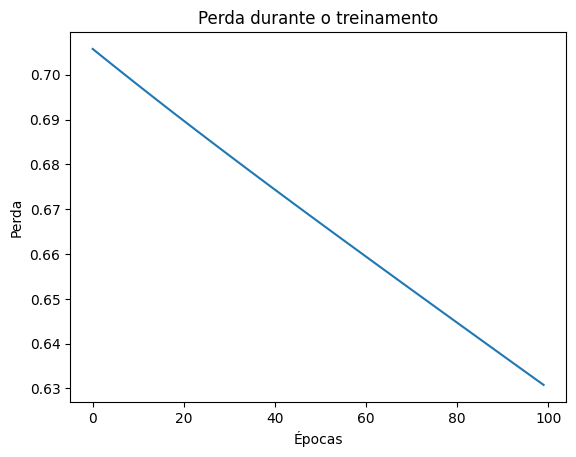

Modelo 2: Tanh, 16 neurônios
Época [100/100], Perda: 0.5243


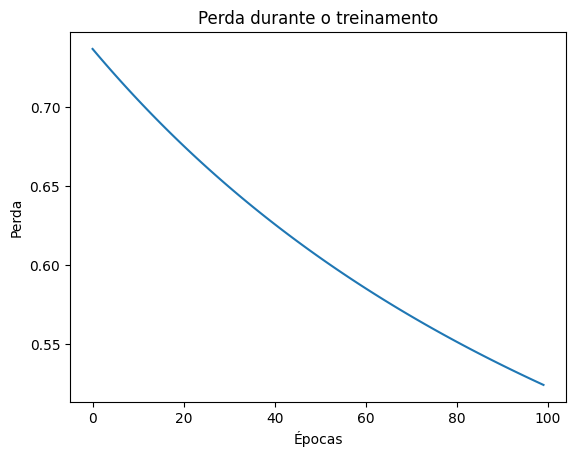

Modelo 3: LeakyReLU, 32 neurônios
Época [100/100], Perda: 0.4949


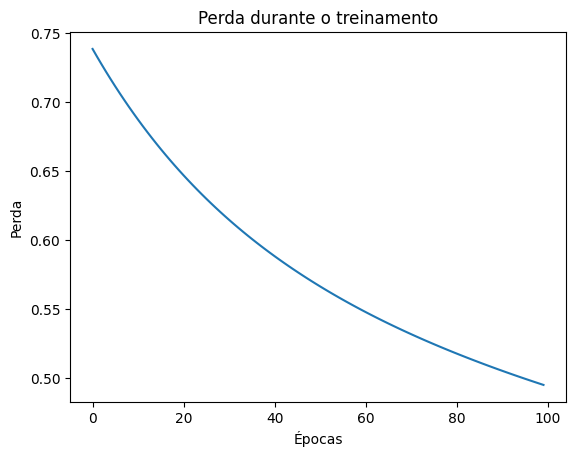

In [34]:
# Importando as bibliotecas que serão utilizadas

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Dados de entrada
iris = load_iris()
X, y = iris.data, iris.target

# Transformando em um problema de classificação binária
y_binary = (y == 2).astype(int)

# Divisão em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)

# Normalizando os dados com Standard Scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertendo para tensores do PyTorch, de forma que possam ser utilizados nas funções posteriormente
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Array de valores de acurácia
acuracias = list()

# Definição da arquitetura da rede com ajustes
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, activation_fn):
        super(MLP, self).__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)  # Define a camada oculta
        self.output = nn.Linear(hidden_dim, 1)          # Defina a camada de saída
        self.activation = activation_fn                 # Define a função de ativação
        self.sigmoid = nn.Sigmoid()                     # Converte a saída em probabilidade

    def forward(self, x):
        x = self.activation(self.hidden(x))  # Aplica a função de ativação depois de x passar pela camada oculta
        x = self.sigmoid(self.output(x))     # Aplica a sigmóide depois de x passar pela camada de saída
        return x

# Função auxiliar para facilitar no treinamento e na avaliação de diferentes modelos,
# recebendo como parâmetros o número de neurônios, a função de ativação e o número de
# épocas
def treina_modelo(hidden_dim, activation_fn, epochs=100):
    model = MLP(input_dim=X_train.shape[1], hidden_dim=hidden_dim, activation_fn=activation_fn)
    criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    loss_history = []
    for epoch in range(epochs):
        # Forward pass
        y_pred = model(X_train_tensor)
        loss = criterion(y_pred, y_train_tensor)

        # Backward pass e otimização
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Armazena o histórico de perda
        loss_history.append(loss.item())

        # Exibe a perda a cada 100 épocas
        if (epoch+1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Perda: {loss.item():.4f}")

    # Armazenamento dos valores de acurácia
    with torch.no_grad():
        y_test_pred = model(X_test_tensor)
        y_test_pred = (y_test_pred >= 0.5).float()
        acuracia = accuracy_score(y_test_tensor.numpy(), y_test_pred.numpy())
        acuracias.append(acuracia)

    # Visualização da perda durante o treinamento
    plt.plot(loss_history)
    plt.title("Perda durante o treinamento")
    plt.xlabel("Épocas")
    plt.ylabel("Perda")
    plt.show()

# Testando diferentes modelos variando-se o número de neurônios e a função de ativação
print("Modelo 1: ReLU, 8 neurônios")
treina_modelo(hidden_dim=8, activation_fn=nn.ReLU())

print("Modelo 2: Tanh, 16 neurônios")
treina_modelo(hidden_dim=16, activation_fn=nn.Tanh())

print("Modelo 3: LeakyReLU, 32 neurônios")
treina_modelo(hidden_dim=32, activation_fn=nn.LeakyReLU())


In [35]:
# Utilize a acuracia para avaliar as previsões

for k, acuracia in enumerate(acuracias):
    print(f"Acurácia do Modelo {k + 1}: {acuracia:.4f}")

Acurácia do Modelo 1: 0.7111
Acurácia do Modelo 2: 0.7778
Acurácia do Modelo 3: 0.9556


## 2.1 - Rede Neural Convolucional (CNN)

Treine 3x redes de CNN simples para classificar o conjunto de dados MNIST, os exemplos estão em Keras do tensorflow mas caso queira adaptar para outra biblioteca fique a vontade.

Começe sempre de um modelo mais simples, como por exemplo 1 camada de convolução com 4 filtros e 1 camada densa com 32 neurônios e vai aumentando a complexidade e realize um comparativo entre a acurácia de cada modelo e a convergencia do modelo nas épocas.

Nota: 4.0

In [36]:
from tensorflow.keras.datasets import mnist
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

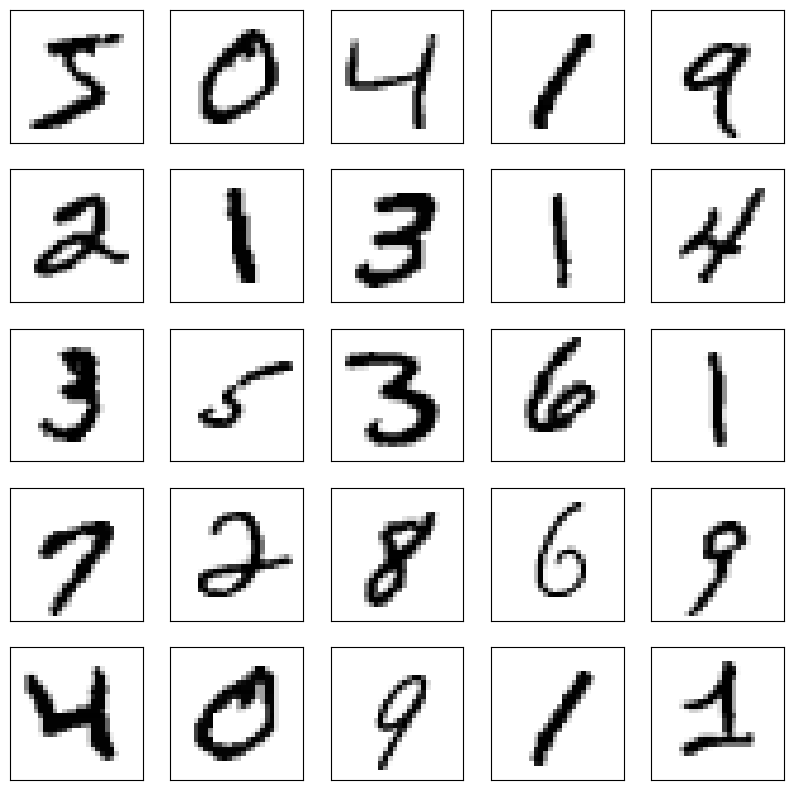

In [37]:
# mostrando algumas imagens do conjunto de treino
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
plt.show()

In [38]:
## CODIGO AQUI

import tensorflow as tf
import tensorflow_datasets as tfds

# Criando pipeline de entrada

(ds_train, ds_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

# Criando pipeline de treinamento

def normalize_img(image, label):
  """Normalizes images: `uint8` -> `float32`."""
  return tf.cast(image, tf.float32) / 255., label

ds_train = ds_train.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache()
ds_train = ds_train.shuffle(ds_info.splits['train'].num_examples)
ds_train = ds_train.batch(128)
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)

# Criando pipeline de avaliação

ds_test = ds_test.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(128)
ds_test = ds_test.cache()
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

# Modelos (complexidade será aumentada mudando-se a quantidade de filtros e neurônios)

# CNN com uma camada de convolução com 4 filtros e uma camada densa com 32 neurônios

modelo1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(4, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

modelo1.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

modelo1.fit(
    ds_train,
    epochs=6,
    validation_data=ds_test,
)

# Adicionando uma camada de convolução com 16 filtros e mudando a qtde de neurônios para 64

modelo2 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(8, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(16, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

modelo2.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

modelo2.fit(
    ds_train,
    epochs=6,
    validation_data=ds_test,
)

# Adicionando mais uma camada de convolução, aumentando o número de filtros e mudando a qtde de neurônios para 128

model_complex = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_complex.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

model_complex.fit(
    ds_train,
    epochs=6,
    validation_data=ds_test,
)

# Comparativo entre a acurácia de cada modelo e a convergencia do modelo nas épocas:
#
# Como é possível perceber, a acurácia ao final das 6 épocas utilizadas foi crescente
# no que diz respeito à sequência de modelos. Sendo assim, o modelo 1 (mais simples)
# atingiu 97.53%, o modelo 2, 98.51%, e o modelo 3, 99.27%, indicando o que é de fato
# esperado: maior complexidade veio acompanhada de maior acurácia.
# No que diz respeito à velocidade de convergência, pode-se realizar a seguinte análise:
# Para o modelo 1, a perda chegou a pouco mais de 0.08 na última época. Para o modelo 2,
# a perda teve uma tendência de estabilização em torno de 0.05 já entre as épocas 4 e 5,
# indicando maior velocidade de convergência. Por fim, a perda do modelo 3 praticamente
# teve sua estabilização já na quarta época, em um valor em torno de 0.03. Portanto,
# é válido afirmar que a velocidade de convergência, bem como sua estabilidade, aumentaram
# conforme a complexidade do modelo.


Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - loss: 0.8863 - sparse_categorical_accuracy: 0.7382 - val_loss: 0.2079 - val_sparse_categorical_accuracy: 0.9392
Epoch 2/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - loss: 0.2029 - sparse_categorical_accuracy: 0.9419 - val_loss: 0.1437 - val_sparse_categorical_accuracy: 0.9568
Epoch 3/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - loss: 0.1410 - sparse_categorical_accuracy: 0.9601 - val_loss: 0.1121 - val_sparse_categorical_accuracy: 0.9667
Epoch 4/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.1119 - sparse_categorical_accuracy: 0.9675 - val_loss: 0.0956 - val_sparse_categorical_accuracy: 0.9707
Epoch 5/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 0.0972 - sparse_categorical_accuracy: 0.9721 - val_loss: 0.0894 - val_sparse_categorical_accuracy: 0.9716
Epoch 6/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 0.0859 - sparse_categorical_accuracy: 0.9753 - val_loss: 0.0834 - val_sparse_categorical_accuracy: 0.973

##  2.2 - Modelos pré treinados

Escolha algum modelo pré treinado (AlexNet, VGG, ResNet, etc) e faça apenas uma versão com esse modelo no conjunto de dados MNIST, compare a acurácia desse modelo com o modelo anterior, a acurácia foi maior? o modelo convergiu mais rápido (menos épocas?), faça uma breve discussão dos resultados.

Nota 2.0

In [45]:
# Foi escolhido o modelo ResNet50

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Model

# Ajustando as imagens para serem compatíveis com ResNet50 (224x224, 3 canais)
def preprocess_images(image, label):
    image = tf.image.grayscale_to_rgb(image)  # Converter de 1 para 3 canais
    image = tf.image.resize(image, (224, 224))  # Redimensionar para 224x224
    return image, label

ds_train_resnet = ds_train.map(preprocess_images)
ds_test_resnet = ds_test.map(preprocess_images)

# Carregar ResNet50 pré-treinada no ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Congelar os pesos do modelo base

# Adicionar camadas de classificação no topo
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(10, activation='softmax')(x)
model_resnet = Model(inputs=base_model.input, outputs=output)

# Compilar e treinar o modelo
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
)

history_resnet = model_resnet.fit(
    ds_train_resnet,
    validation_data=ds_test_resnet,
    epochs=6
)

# Não foi possível completar o treinamento, pois o tempo seria muito longo.
# Só para treinar a primeira época a duração estimada era de mais de 7 horas.
# Tentei com outros modelos, AlexNet e VGG16 mas todos iriam demorar no mínimo
# 3 horas somente na primeira época.


Epoch 1/6


  1/469 ━━━━━━━━━━━━━━━━━━━━ 7:00:41 54s/step - loss: 2.7505 - sparse_categorical_accuracy: 0.0938

KeyboardInterrupt: 